# Muhammad Rizqi Nurrohmat - 0110224001
# Machine Learning - Latihan 1 - Algoritma KNN

## ***Import Library***

In [46]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## ***Dataset (raining)***

In [47]:
data = {
    'temperatur': [10 , 25, 15, 20, 18, 20, 22, 24],
    'Angin': [0, 0, 5, 3, 7, 10, 5, 6],
    'Persepsi': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas' ]
}

df = pd.DataFrame(data)

# menyimpan dataframe ke file CSV
df.to_csv('../data/data_latihan1.csv', index=False)
df


,temperatur,Angin,Persepsi
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


## ***Fitur dan Label***

In [48]:
x = df[['temperatur', 'Angin']]
y = df['Persepsi']

## ***Splitting dataset***

In [49]:
X_latih, X_uji, y_latih, y_uji = train_test_split(x, y, test_size=0.2, random_state=42)

## ***Cari Akurasi untuk Setiap Nilai K***

In [50]:
max_k = len(X_latih)
akurasi = []
for k in range(1, max_k + 1):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_latih, y_latih)
    y_pred = model.predict(X_uji)
    akurasi.append(accuracy_score(y_uji, y_pred))

## ***Visualisasi Akurasi vs Nilai K***

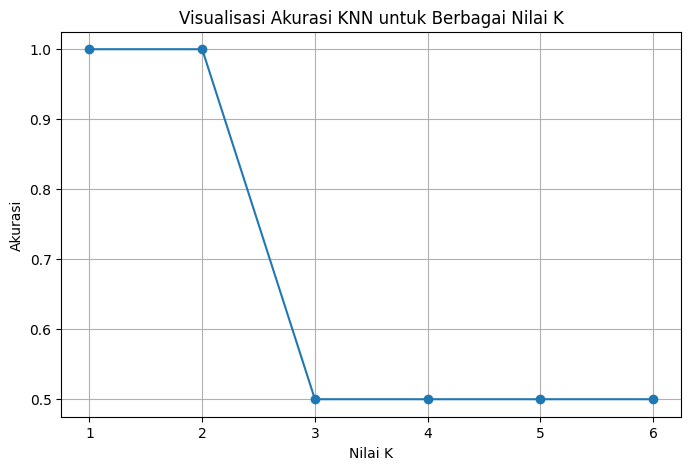

In [51]:
plt.figure(figsize=(8,5))
plt.plot(range(1, max_k + 1), akurasi, marker='o')
plt.title('Visualisasi Akurasi KNN untuk Berbagai Nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.grid(True)
plt.show()

## ***Pilih K Terbaik & training final***

In [58]:
nilai_k_terbaik = akurasi.index(max(akurasi)) + 1
model_final = KNeighborsClassifier(n_neighbors=nilai_k_terbaik)
model_final.fit(X_latih, y_latih)

print("Nilai K terbaik:", nilai_k_terbaik)
print("Akurasi tertinggi:", max(akurasi))

Nilai K terbaik: 1
Akurasi tertinggi: 1.0


## **Prediksi Persepsi Marry (temperatur = 16, angin = 3)**

In [59]:
fitur_marry = [[16, 3]]  # Sesuaikan urutan fitur dengan data
prediksi_marry = model_final.predict(fitur_marry)
print("Prediksi Persepsi Marry:", prediksi_marry[0])

Prediksi Persepsi Marry: Dingin


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
